# EXEMPLO PREENCHIDO — Projeto com estrutura inspirada em dados do IBGE

**ID:** `PI-EXEMPLO-IBGE-SINTETICO`

> **Dados inteiramente fictícios:** este notebook não contém estatísticas
> oficiais, não foi produzido pelo IBGE e não deve ser citado como fonte sobre
> o Brasil. Municípios, códigos e valores foram simulados para ensinar a
> estrutura de uma entrega reprodutível.

## Pergunta do projeto

Como a alfabetização varia entre 2010 e 2022 no corpus municipal sintético,
e como essa variação se relaciona com urbanização inicial e grandes regiões?

## Forma da entrega

O notebook intercala problema, código, tabelas, gráficos, interpretação e
limites. O código aparece quando produz uma evidência necessária; decisões
metodológicas que não exigem cálculo permanecem argumentadas em texto.

## U01 — Proposta inicial


**ID:** `PI-EXEMPLO-IBGE-SINTETICO` — versão `v0.1-proposta`.

**Problema:** investigar desigualdades municipais de alfabetização e sua relação
com urbanização entre dois momentos censitários.

**Pergunta delimitada:** como a taxa de alfabetização varia entre 2010 e 2022
nos municípios do corpus simulado, e como essa variação se relaciona com a
urbanização inicial e com as grandes regiões?

**Unidade:** município-ano. **Corpus pretendido:** indicadores de 60 municípios
fictícios observados em 2010 e 2022.

**Cuidado:** a pergunta é descritiva e associativa. Ela não permite afirmar que
a urbanização cause mudanças na alfabetização.

## U02 — Protocolo da base


**Fonte de referência:** estrutura inspirada em tabelas municipais disponibilizadas
pelo IBGE/SIDRA. Nesta demonstração, porém, nenhum valor foi coletado do IBGE.

**População conceitual:** municípios brasileiros nos dois anos. **Corpus
didático:** 60 municípios inventados, doze por grande região, com duas
observações por município.

**Campos planejados:** código municipal fictício, nome fictício, região, ano,
população, urbanização, alfabetização e renda domiciliar per capita.

**Proveniência:** o gerador, a semente aleatória e as regras de simulação ficam
no notebook. Uma pesquisa real registraria tabela SIDRA, código da variável,
unidade, classificação, data de acesso e notas metodológicas.

## U03 — Primeira base processável


**Estrutura:** base em formato longo, com uma linha por município-ano e chave
composta por `codigo_municipio` e `ano`.

**Transformações previstas:** validar chaves, tipos e intervalos; preservar os
códigos como texto; conferir duas observações por município; manter percentuais
em escala de 0 a 100.

**Produto:** `painel_municipal_sintetico-v1`, com 120 linhas e dicionário de
dados. Os nomes “Município fictício 001” etc. impedem associação com localidades
reais.

### Demonstração técnica — gerar o painel municipal sintético

Esta célula imita a forma de uma base municipal, mas não seus valores.
A semente torna a simulação reproduzível. Em uma pesquisa real, o código
começaria pela importação e pela documentação da tabela oficial.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
municipios = pd.DataFrame({
    "codigo_municipio": [f"F{i:05d}" for i in range(1, 61)],
    "municipio": [f"Município fictício {i:03d}" for i in range(1, 61)],
    "regiao": np.repeat(regioes, 12),
})

efeito_regiao = {
    "Norte": -5, "Nordeste": -7, "Sudeste": 6,
    "Sul": 5, "Centro-Oeste": 1,
}
municipios["urbanizacao_2010"] = np.clip(
    62 + municipios["regiao"].map(efeito_regiao)
    + rng.normal(0, 11, len(municipios)), 25, 95
)
municipios["alfabetizacao_2010"] = np.clip(
    67 + 0.24 * municipios["urbanizacao_2010"]
    + municipios["regiao"].map(efeito_regiao) * 0.25
    + rng.normal(0, 2.8, len(municipios)), 60, 98
)
municipios["populacao_2010"] = np.exp(
    rng.normal(np.log(65000), 0.75, len(municipios))
).round().astype(int)

linhas = []
for ano in [2010, 2022]:
    posterior = ano == 2022
    bloco = municipios[[
        "codigo_municipio", "municipio", "regiao"
    ]].copy()
    bloco["ano"] = ano
    bloco["populacao"] = (
        municipios["populacao_2010"]
        * (1 + (rng.normal(0.10, 0.08, len(municipios)) if posterior else 0))
    ).round().clip(lower=1000).astype(int)
    bloco["urbanizacao_pct"] = np.clip(
        municipios["urbanizacao_2010"]
        + (rng.normal(5.5, 1.8, len(municipios)) if posterior else 0),
        20, 99,
    ).round(1)
    bloco["alfabetizacao_pct"] = np.clip(
        municipios["alfabetizacao_2010"]
        + (4 + 0.035 * municipios["urbanizacao_2010"]
           + rng.normal(0, 1.2, len(municipios)) if posterior else 0),
        55, 99.5,
    ).round(1)
    bloco["renda_pc"] = np.clip(
        420 + 11 * bloco["urbanizacao_pct"]
        + bloco["regiao"].map(efeito_regiao) * 12
        + (260 if posterior else 0)
        + rng.normal(0, 120, len(municipios)),
        250, None,
    ).round(0)
    linhas.append(bloco)

ibge_sintetico = pd.concat(linhas, ignore_index=True).sort_values(
    ["codigo_municipio", "ano"]
).reset_index(drop=True)
display(ibge_sintetico.head(8))

,codigo_municipio,municipio,regiao,ano,populacao,urbanizacao_pct,alfabetizacao_pct,renda_pc
0,F00001,Município fictício 001,Norte,2010,150395,48.3,74.6,1028.0
1,F00001,Município fictício 001,Norte,2022,195969,53.9,82.7,1130.0
2,F00002,Município fictício 002,Norte,2010,46091,59.6,77.3,1092.0
3,F00002,Município fictício 002,Norte,2022,54311,63.3,82.6,1491.0
4,F00003,Município fictício 003,Norte,2010,38988,36.1,71.7,885.0
5,F00003,Município fictício 003,Norte,2022,44924,43.6,76.1,1217.0
6,F00004,Município fictício 004,Norte,2010,141688,72.4,79.1,1069.0
7,F00004,Município fictício 004,Norte,2022,143134,80.7,86.0,1423.0


In [2]:
verificacoes_ibge = pd.Series({
    "linhas": len(ibge_sintetico),
    "municípios únicos": ibge_sintetico["codigo_municipio"].nunique(),
    "chaves município-ano únicas": int(
        ~ibge_sintetico.duplicated(["codigo_municipio", "ano"]).any()
    ),
    "observações por município": sorted(
        ibge_sintetico.groupby("codigo_municipio").size().unique().tolist()
    ),
    "percentuais fora de 0–100": int(
        (~ibge_sintetico["alfabetizacao_pct"].between(0, 100)).sum()
        + (~ibge_sintetico["urbanizacao_pct"].between(0, 100)).sum()
    ),
}, name="resultado")
display(verificacoes_ibge.to_frame())

,resultado
linhas,120
municípios únicos,60
chaves município-ano únicas,1
observações por município,[2]
percentuais fora de 0–100,0


**Análise da preparação.** As 120 linhas correspondem a 60 municípios
observados duas vezes. A chave município-ano é única e os percentuais
permanecem nos intervalos esperados. Isso verifica a estrutura do painel,
não a autenticidade ou a representatividade dos valores.

## U04 — Relatório exploratório


**Exploração:** comparar centro, dispersão e distribuição das taxas por ano;
observar a relação entre urbanização e alfabetização; conferir diferenças de
cobertura antes de interpretar padrões.

**Evidência esperada:** tabelas resumidas e gráficos que mostrem tanto a mudança
agregada quanto a heterogeneidade entre municípios.

**Limite:** o processo gerador foi construído para produzir associações didáticas;
seus resultados não descrevem o Brasil.

### Exploração — centro, dispersão e associação visual

A tabela resume os anos separadamente. Os gráficos mostram a mudança da
distribuição e a relação municipal entre urbanização e alfabetização.

In [3]:
resumo_ibge = ibge_sintetico.groupby("ano").agg(
    municipios=("codigo_municipio", "nunique"),
    alfabetizacao_media=("alfabetizacao_pct", "mean"),
    alfabetizacao_mediana=("alfabetizacao_pct", "median"),
    alfabetizacao_dp=("alfabetizacao_pct", "std"),
    urbanizacao_media=("urbanizacao_pct", "mean"),
)
display(resumo_ibge.round(2))

,municipios,alfabetizacao_media,alfabetizacao_mediana,alfabetizacao_dp,urbanizacao_media
ano,,,,,
2010,60,82.11,82.0,4.61,64.50
2022,60,88.47,88.4,5.16,69.76


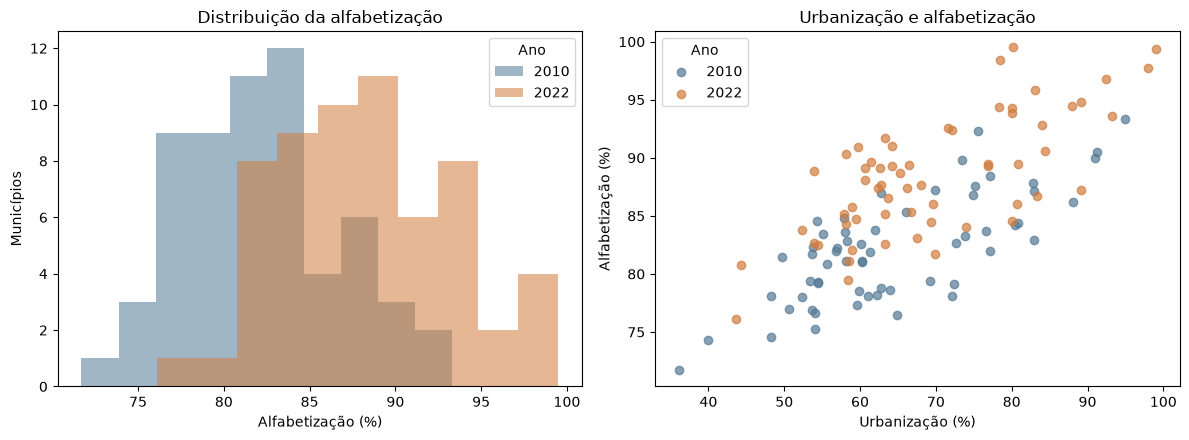

In [4]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
for ano, cor in [(2010, "#557a95"), (2022, "#d07c3e")]:
    recorte = ibge_sintetico[ibge_sintetico["ano"].eq(ano)]
    eixos[0].hist(
        recorte["alfabetizacao_pct"], bins=10, alpha=0.55,
        color=cor, label=str(ano),
    )
    eixos[1].scatter(
        recorte["urbanizacao_pct"], recorte["alfabetizacao_pct"],
        alpha=0.7, color=cor, label=str(ano),
    )
eixos[0].set_title("Distribuição da alfabetização")
eixos[0].set_xlabel("Alfabetização (%)")
eixos[0].set_ylabel("Municípios")
eixos[0].legend(title="Ano")
eixos[1].set_title("Urbanização e alfabetização")
eixos[1].set_xlabel("Urbanização (%)")
eixos[1].set_ylabel("Alfabetização (%)")
eixos[1].legend(title="Ano")
plt.tight_layout()
plt.show()

**Análise dos gráficos.** A distribuição de 2022 se desloca para taxas
de alfabetização maiores, embora permaneça sobreposição entre os anos.
No diagrama de dispersão, municípios mais urbanizados tendem a apresentar
alfabetização maior. A nuvem não forma uma linha perfeita: municípios
com urbanização semelhante ainda diferem, lembrando que uma única variável
não explica todo o fenômeno.

## U05 — Análise comparativa


**Comparação principal:** mudança da alfabetização em cada município entre 2010
e 2022. O pareamento pelo código evita comparar conjuntos municipais diferentes.

**Sensibilidade:** observar a mudança média segundo faixas de urbanização inicial
e segundo região. Diferenças agregadas não substituem a inspeção da distribuição
das mudanças municipais.

**Interpretação:** grupos podem apresentar mudanças distintas, mas a simulação
não oferece desenho causal nem representa amostra probabilística.

### Comparação pareada — a mudança dentro de cada município

Em vez de comparar apenas duas médias agregadas, reorganizamos a base
para calcular quanto cada município mudou entre os dois anos.

In [5]:
painel_mudanca = ibge_sintetico.pivot(
    index=["codigo_municipio", "municipio", "regiao"],
    columns="ano",
    values=["alfabetizacao_pct", "urbanizacao_pct"],
).reset_index()
painel_mudanca.columns = [
    "codigo_municipio", "municipio", "regiao",
    "alfabetizacao_2010", "alfabetizacao_2022",
    "urbanizacao_2010", "urbanizacao_2022",
]
painel_mudanca["mudanca_alfabetizacao_pp"] = (
    painel_mudanca["alfabetizacao_2022"]
    - painel_mudanca["alfabetizacao_2010"]
)
painel_mudanca["faixa_urbanizacao_inicial"] = pd.qcut(
    painel_mudanca["urbanizacao_2010"], 3,
    labels=["menor", "intermediária", "maior"],
)
mudanca_por_faixa = painel_mudanca.groupby(
    "faixa_urbanizacao_inicial", observed=True
)["mudanca_alfabetizacao_pp"].agg(["count", "mean", "median", "std"])
display(mudanca_por_faixa.round(2))

,count,mean,median,std
faixa_urbanizacao_inicial,,,,
menor,20,6.13,6.10,1.42
intermediária,20,6.20,6.00,1.04
maior,20,6.74,6.75,1.09


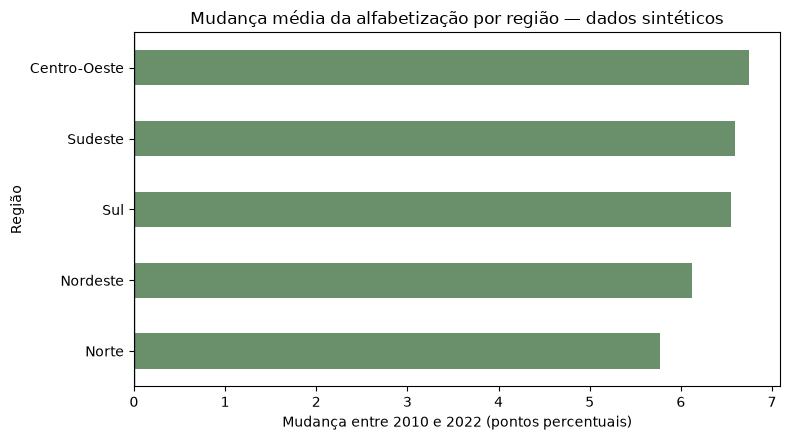

In [6]:
media_regional = painel_mudanca.groupby("regiao")[
    "mudanca_alfabetizacao_pp"
].mean().sort_values()
media_regional.plot.barh(figsize=(8, 4.5), color="#6a8f6b")
plt.axvline(0, color="#333333", linewidth=1)
plt.title("Mudança média da alfabetização por região — dados sintéticos")
plt.xlabel("Mudança entre 2010 e 2022 (pontos percentuais)")
plt.ylabel("Região")
plt.tight_layout()
plt.show()

**Análise da comparação.** Todas as faixas apresentam mudança média
positiva no conjunto gerado, mas com dispersão interna. O gráfico regional
facilita comparar magnitudes, sem transformar região em explicação causal.
Como cada barra resume doze municípios fictícios, a média não deve apagar
casos municipais divergentes.

## U06 — Associação ou rede


**Decisão:** não incorporar redes. As linhas descrevem municípios e indicadores,
mas não contêm relações como fluxos migratórios, deslocamentos ou vínculos
institucionais.

**Risco de forçar o método:** criar arestas apenas por semelhança de indicadores
produziria uma rede analítica, não uma rede social ou territorial observada.

**Alternativa:** preservar comparações, distribuições e associações entre
variáveis, que respondem melhor à pergunta.

## U07 — Regressão


**Decisão:** incorporar uma regressão linear descritiva simples como diagnóstico
da associação entre urbanização e alfabetização em 2022.

**Resposta:** taxa de alfabetização. **Característica:** taxa de urbanização.
A inclinação resume uma associação média no corpus sintético.

**Limites:** regiões, renda, história municipal, composição demográfica e erro
de medição não são controlados. O coeficiente não deve receber interpretação
causal nem ser generalizado para municípios reais.

### Regressão descritiva — resumir uma associação

O ajuste abaixo descreve a inclinação da relação em 2022. Ele é usado
como síntese visual e numérica, não como prova de causalidade.

,estimativa
inclinação por 1 p.p. de urbanização,0.287
R²,0.508
n,60.000


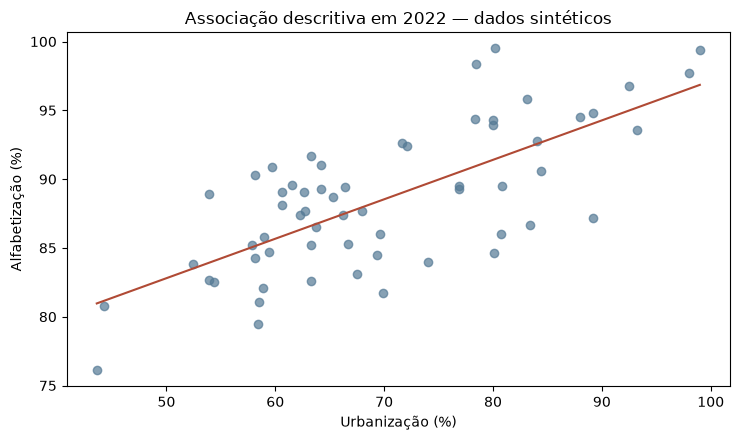

In [7]:
dados_2022 = ibge_sintetico[ibge_sintetico["ano"].eq(2022)].copy()
inclinacao, intercepto = np.polyfit(
    dados_2022["urbanizacao_pct"],
    dados_2022["alfabetizacao_pct"], 1,
)
previsto = intercepto + inclinacao * dados_2022["urbanizacao_pct"]
r2 = 1 - (
    ((dados_2022["alfabetizacao_pct"] - previsto) ** 2).sum()
    / ((dados_2022["alfabetizacao_pct"]
        - dados_2022["alfabetizacao_pct"].mean()) ** 2).sum()
)
display(pd.Series({
    "inclinação por 1 p.p. de urbanização": inclinacao,
    "R²": r2,
    "n": len(dados_2022),
}, name="estimativa").to_frame().round(3))

x_linha = np.linspace(
    dados_2022["urbanizacao_pct"].min(),
    dados_2022["urbanizacao_pct"].max(), 100,
)
plt.figure(figsize=(7.5, 4.5))
plt.scatter(
    dados_2022["urbanizacao_pct"], dados_2022["alfabetizacao_pct"],
    alpha=0.7, color="#557a95",
)
plt.plot(x_linha, intercepto + inclinacao * x_linha, color="#b04a35")
plt.title("Associação descritiva em 2022 — dados sintéticos")
plt.xlabel("Urbanização (%)")
plt.ylabel("Alfabetização (%)")
plt.tight_layout()
plt.show()

**Análise do ajuste.** A inclinação positiva resume a direção observada:
no corpus simulado, urbanização maior está associada a alfabetização
maior. O $R^2$ informa quanta variação o ajuste linear resume, não a
importância histórica da variável. O modelo omite outros fatores e não
autoriza a frase “urbanização aumenta a alfabetização”.

## U08 — Classificação


**Decisão:** não incorporar classificação. Transformar alfabetização contínua em
“alta” e “baixa” apagaria variações e exigiria um limiar substantivo que a
pergunta não fornece.

**Aprendizagem transferida:** se uma política pública futura definisse uma classe
de prioridade, seria necessário documentar o rótulo, avaliar erros entre grupos
e comparar o modelo com uma regra simples.

## U09 — Agrupamento ou tópicos


**Decisão:** não incorporar agrupamento ao argumento principal. Um piloto poderia
agrupar perfis municipais, mas os grupos dependeriam de escala, variáveis e número
de clusters.

**Risco:** nomear clusters como “municípios desenvolvidos” naturalizaria uma
construção algorítmica e multidimensional sem fundamentação conceitual suficiente.

## U10 — Extração de informações


**Decisão:** não incorporar extração de informações. A base já é tabular e não
contém documentos dos quais entidades ou relações precisem ser extraídas.

**Possível extensão:** atas, relatórios municipais ou descrições metodológicas
poderiam formar outro corpus, com unidade e cadeia de evidência próprias. Essa
extensão não é necessária para responder à pergunta atual.

## U11 — Tempo ou espaço


**Decisão:** incorporar comparação temporal limitada a dois pontos. O notebook
não chama essa diferença de tendência contínua, pois não observa os anos
intermediários.

**Análise espacial não incorporada:** o exemplo não possui geometrias nem códigos
oficiais. Colorir um mapa com municípios inventados seria enganoso. Região é
utilizada apenas como categoria agregada.

### Comparação temporal agregada por região

Com apenas dois anos, podemos mostrar diferenças entre pontos, mas não
trajetórias contínuas. Cada linha abaixo liga duas médias regionais.

ano,2010,2022
regiao,,
Centro-Oeste,84.42,91.17
Nordeste,79.12,85.24
Norte,77.62,83.38
Sudeste,84.72,91.32
Sul,84.68,91.23


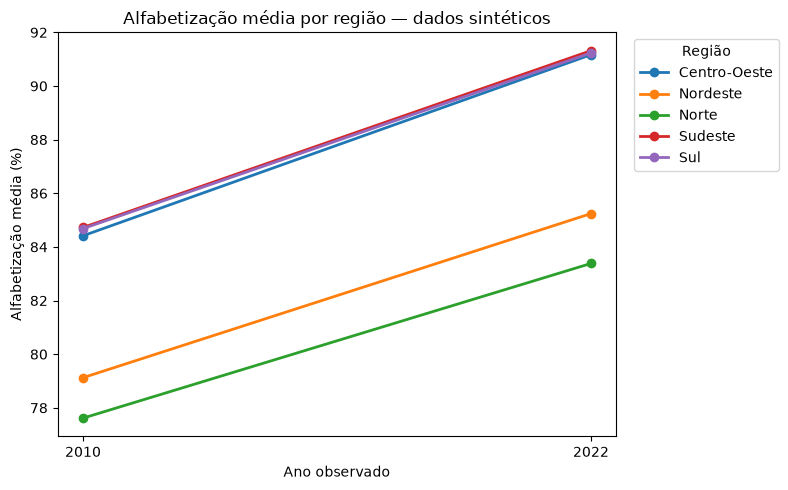

In [8]:
regional_ano = ibge_sintetico.groupby(["regiao", "ano"])[
    "alfabetizacao_pct"
].mean().unstack("ano")
display(regional_ano.round(2))

fig, eixo = plt.subplots(figsize=(8, 5))
for regiao, valores in regional_ano.iterrows():
    eixo.plot(
        [2010, 2022], [valores[2010], valores[2022]],
        marker="o", linewidth=2, label=regiao,
    )
eixo.set_title("Alfabetização média por região — dados sintéticos")
eixo.set_xlabel("Ano observado")
eixo.set_ylabel("Alfabetização média (%)")
eixo.set_xticks([2010, 2022])
eixo.legend(title="Região", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Análise do gráfico.** Todas as linhas terminam acima de seu ponto
inicial porque a simulação incorporou crescimento. As diferenças de
altura entre regiões também foram parcialmente programadas. O espaço
entre 2010 e 2022 não contém observações; ligar os pontos ajuda a comparar,
mas não demonstra uma evolução linear durante os anos intermediários.

## U12 — Modelos de linguagem


**Decisão:** não incorporar modelo de linguagem. A pergunta é respondida com
variáveis numéricas documentadas; gerar resumos automáticos não acrescentaria
evidência e poderia produzir afirmações incompatíveis com a natureza sintética.

**Uso responsável possível:** auxiliar a revisão da clareza do texto, mantendo
verificação humana e sem apresentar texto gerado como análise empírica.

## U13 — Validade e robustez


**Validade de construto:** alfabetização e urbanização são representadas por um
único indicador simulado cada; os conceitos sociais são mais amplos que essas
colunas.

**Robustez:** comparar média e mediana, examinar municípios extremos e repetir a
análise por região. A associação positiva permanece no conjunto gerado, mas sua
magnitude depende das regras da simulação.

**Ameaça decisiva:** validade externa inexistente. O corpus ensina um percurso de
análise, não produz conhecimento sobre municípios brasileiros reais.

## U14 — Projeto final


**Versão:** `v1.0-exemplo-sintetico`.

**Resultado central:** no conjunto fictício, alfabetização aumenta entre os dois
momentos e se associa positivamente à urbanização, com heterogeneidade regional
e municipal.

**Métodos incorporados:** exploração, comparação pareada, sensibilidade, regressão
descritiva e comparação temporal de dois pontos. **Métodos recusados:** redes,
classificação, clusters como argumento, extração e modelos de linguagem.

**Próxima etapa real:** substituir a simulação por uma consulta documentada ao
SIDRA, reconstruir o dicionário a partir dos metadados oficiais e reavaliar todas
as conclusões.

## Síntese do exemplo

Este percurso mostra que usar uma estrutura semelhante à de dados públicos
não dispensa documentação, validação de chaves, definição dos denominadores,
comparação de distribuições e cautela causal. A substituição futura pelos
dados oficiais exige nova auditoria; resultados sintéticos não podem ser
transportados para o Brasil real.